In [2]:
# general-use imports
import numpy as np
import pickle
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
import arviz as az

# custom imports
from settings import DATA_DIR
from nteprsm import utils
from nteprsm.constants import NTEP_COLOR_SCALE
import rutils
rutils.set_custom_template()
NTEP_COLOR_SCALE_list = list(NTEP_COLOR_SCALE.values())

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/Users/henryqu/Library/Caches/pypoetry/virtualenvs/nteprsm-kiQW9mOZ-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the data for visualizations 

In [3]:
# modify file paths as needed
file_path = DATA_DIR/'data_ingestion/parsed_data/kb2017/nj2/quality.csv'
fit_object_path = DATA_DIR/'model_output/kb2017/fit_seasonality_nj2_quality.pkl'
fit_object_path_old = DATA_DIR/'model_output/kb2017/fit_spatial_nj2_quality.pkl'

# load raw data
datahandler = utils.DataHandler(filepath=file_path)
datahandler.preprocess_data()
datahandler.generate_stan_data()
# load fit object from a previously trained model
with open(fit_object_path, 'rb') as file:
    fit = pickle.load(file)
# load fit object from a previously trained OLD (SPATIAL) model
with open(fit_object_path_old, 'rb') as file:
    fit_old_model = pickle.load(file)

2026-05-06 07:53:12,410 - NtepRsm - INFO - Raw data successfully loaded.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:244: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")
2026-05-06 07:53:12,449 - NtepRsm - INFO - Preprocessing complete. Model data ready.
2026-05-06 07:53:12,456 - NtepRsm - INFO - Stan data dictionary created.


## Histogram of raw ratings distribution

In [4]:
# prepare data
model_data = datahandler.model_data
rater_mapping = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G'}
model_data['rater_display_code'] = model_data['rater_code'].map(rater_mapping)
model_data['value_original'] = model_data['value']+1

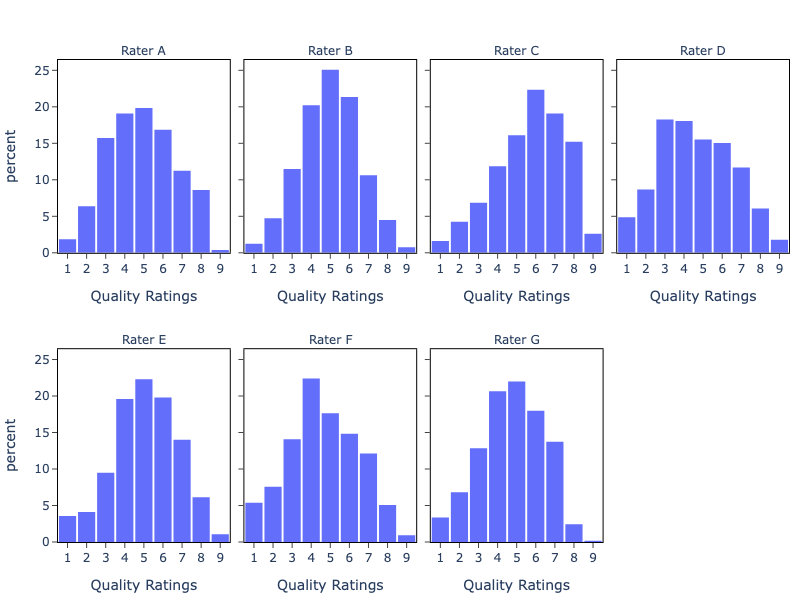

In [5]:
# make a figure
fig = px.histogram(
    model_data, 
    x='value_original', 
    facet_col='rater_display_code', 
    facet_col_wrap=4,
    facet_row_spacing=0.2,
    histnorm='percent',
    nbins=10,
    category_orders = {
        'rater_display_code': rater_mapping.values()
    }
)
fig.for_each_annotation(lambda a: a.update(text='Rater ' + a.text.split('=')[-1]))
fig.update_xaxes(
    tickmode='array',
    showticklabels=True,
    tickvals=list(range(0,10)),
    title='Quality Ratings'
)
fig.update_layout(bargap=0.1, margin=dict(l=10, r=10, b=10, t=60))

# adjust figure size here for static renderer for plotly
# for interactive plot adjust figure size inside `update_layout`
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 600
fig.show(renderer='png') # change to renderer="iframe" for interactive plot
#fig.write_image('figures/fig_raw_data_hist.png')

## Spatial effect comparison

In [9]:
# prepare data for spatial-effect comparison across all four models
grouped = datahandler.model_data.groupby('plot_id')[['row', 'col']].mean().sort_index()
hmap_y = grouped['row'].to_numpy()
hmap_x = grouped['col'].to_numpy()

# ensure the two ablation fits are available when this section is run on its own
fit_spatial_rater_path = DATA_DIR/'model_output/kb2017/fit_spatial_rater_thresholds_nj2_quality.pkl'
fit_annual_oldthr_path = DATA_DIR/'model_output/kb2017/fit_annual_old_thresholds_nj2_quality.pkl'

if 'fit_spatial_rater' not in globals():
    with open(fit_spatial_rater_path, 'rb') as f:
        fit_spatial_rater = pickle.load(f)
if 'fit_annual_oldthr' not in globals():
    with open(fit_annual_oldthr_path, 'rb') as f:
        fit_annual_oldthr = pickle.load(f)

spatial_effect_panels = {
    'Seasonality + original rating model': fit_annual_oldthr.plot_effect.mean(axis=0),
    'Seasonality + rater thresholds': fit.plot_effect.mean(axis=0),
    'Spatial + original rating model': fit_old_model.plot_effect.mean(axis=0),
    'Spatial + rater thresholds': fit_spatial_rater.plot_effect.mean(axis=0),
}

spatial_effect_order = [
    'Seasonality + original rating model',
    'Seasonality + rater thresholds',
    'Spatial + original rating model',
    'Spatial + rater thresholds',
]

all_samples = np.concatenate([spatial_effect_panels[name] for name in spatial_effect_order])
z_limit = float(np.max(np.abs(all_samples)))

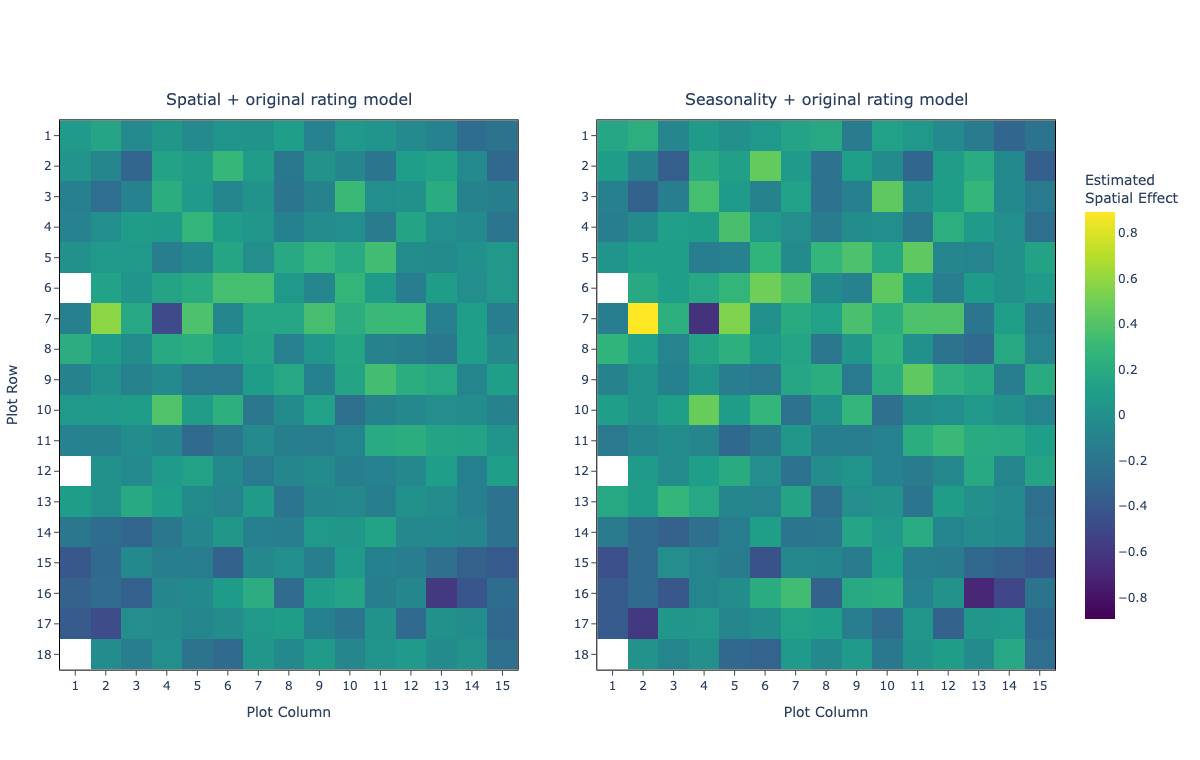

In [24]:
# make a figure with spatial effects for the matched original-rating models
selected_models = [
    'Spatial + original rating model',
    'Seasonality + original rating model',
]
selected_panels = {name: spatial_effect_panels[name] for name in selected_models}
selected_z_limit = float(np.max(np.abs(np.concatenate([selected_panels[name] for name in selected_models]))))

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=selected_models,
    shared_xaxes=False,
    shared_yaxes=False,
    column_widths=[1, 1],
    horizontal_spacing=0.08,
)

unique_x = np.unique(hmap_x)
unique_y = np.unique(hmap_y)

for index, model_name in enumerate(selected_models):
    col = index + 1
    fig.add_trace(
        go.Heatmap(
            z=selected_panels[model_name],
            x=hmap_x,
            y=hmap_y,
            coloraxis='coloraxis',
            hovertemplate='Column %{x}<br>Row %{y}<br>Effect %{z:.3f}<extra></extra>',
        ),
        row=1,
        col=col,
    )

for col in (1, 2):
    fig.update_xaxes(
        title_text='Plot Column',
        tickmode='array',
        tickvals=unique_x,
        ticktext=unique_x,
        row=1,
        col=col,
    )
    fig.update_yaxes(
        title_text='Plot Row' if col == 1 else None,
        tickmode='array',
        tickvals=unique_y,
        ticktext=unique_y,
        autorange='reversed',
        scaleanchor=f'x{col if col > 1 else ""}',
        scaleratio=1,
        constrain='domain',
        row=1,
        col=col,
    )

fig.update_layout(
    title=dict(
        text='',
        x=0.5,
        xanchor='center',
        y=0.98,
        yanchor='top',
    ),
    autosize=False,
    width=1200,
    height=760,
    margin=dict(l=30, r=90, b=80, t=110),
    coloraxis=dict(
        colorscale='viridis',
        cmin=-selected_z_limit,
        cmax=selected_z_limit,
        colorbar=dict(
            title='Estimated <br>Spatial Effect',
            len=0.82,
            y=0.5,
            x=1.02,
            xanchor='left',
        ),
    ),
)

# adjust figure size here for static renderer for plotly
pio.kaleido.scope.default_width = 1200
pio.kaleido.scope.default_height = 760
fig.show(renderer='png')  # change to renderer="iframe" for interactive plot
fig.write_image('/Users/henryqu/Documents/GitHub/nteprsm/reports/manuscript2/figure5_spatial_effect_comp.png')

## Seasonality Curves

In [10]:
# prepare data/labels
name2code = rutils.map_name2code(datahandler, 'entry_name', 'entry_code', invert=True)
print(name2code)

{75: 'A-15-6', 76: 'A-16-17', 73: 'A-16-2', 78: 'A06-8', 71: 'A10-280', 67: 'A11-26', 69: 'A11-38', 1: 'A11-40', 66: 'A12-34', 2: 'A13-1', 64: 'A16-1', 65: 'A16-7', 3: 'A99-2897', 9: 'AKB3128', 10: 'AKB3179', 11: 'AKB3241', 70: 'Acoustic PPG-KB 1131', 15: 'After Midnight', 38: 'Amaze', 42: 'Aviator II', 20: 'BAR PP 71213', 25: 'BAR PP 7236V', 21: 'BAR PP 7309V', 22: 'BAR PP 79366', 26: 'BAR PP 79494', 24: 'BAR PP 7K426', 8: 'Babe', 27: 'Barserati', 23: 'Barvette HGT', 44: 'Blue Devil', 32: 'Blue Gem', 5: 'Blue Knight', 46: 'Bombay', 48: 'Cloud', 39: 'Comanche', 49: 'DLFPS-340/3364', 55: 'DLFPS-340/3438', 58: 'DLFPS-340/3444', 50: 'DLFPS-340/3446', 59: 'DLFPS-340/3455', 53: 'DLFPS-340/3494', 54: 'DLFPS-340/3500', 57: 'DLFPS-340/3548', 56: 'DLFPS-340/3549', 60: 'DLFPS-340/3550', 61: 'DLFPS-340/3551', 62: 'DLFPS-340/3552', 52: 'DLFPS-340/3553', 51: 'DLFPS-340/3556', 83: 'Dublin', 82: 'Electric', 40: 'Finish Line', 41: 'Heartland', 16: 'J-1138', 17: 'J-1319', 18: 'J-2726', 29: 'Jersey', 13

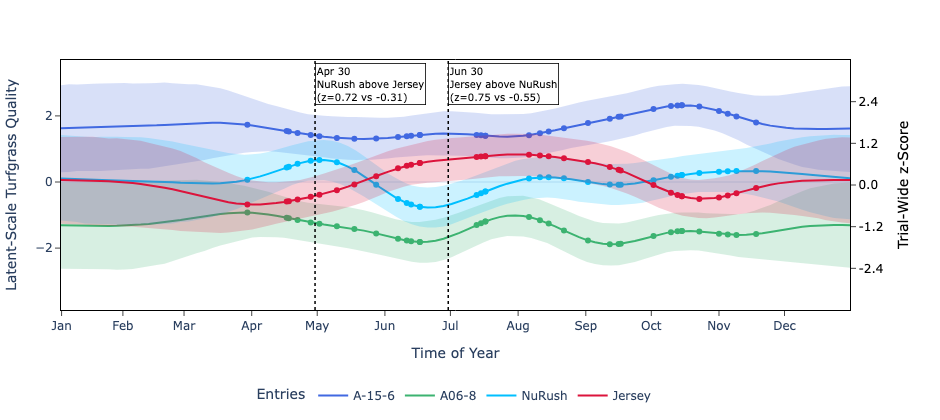

In [11]:
# change entry codes to visualize other varieties
entries = [7, 19, 29, 56]
entries = [75, 78, 19, 29]
colors = ['royalblue', 'mediumseagreen', 'deepskyblue', 'crimson']
ci = 0.95  # Credible interval

fig = go.Figure()

data_points = rutils.extract_time_effect(datahandler, fit)
data_points_time = data_points.index.values

all_samples = fit.pred_time_effect
overall_mean = float(all_samples.mean())
overall_sd = float(all_samples.std())

curve_mean = fit.pred_time_effect.mean(axis=0)
selected_days = {'Apr 30': 120, 'Jun 30': 181}

entry_y_min = np.inf
entry_y_max = -np.inf
entry_day_stats = {}

for i, entry in enumerate(entries):
    entry_name = name2code[entry]
    legend_group = f'Entry {entry_name}'
    samples = fit.pred_time_effect[:, entry, :]

    time_points = np.arange(samples.shape[1]) + 1
    mean_values = np.mean(samples, axis=0)
    lower_bound = np.percentile(samples, 100 * (1 - ci) / 2, axis=0)
    upper_bound = np.percentile(samples, 100 * (ci + (1 - ci) / 2), axis=0)

    entry_y_min = min(entry_y_min, float(lower_bound.min()), float(data_points[entry].min()))
    entry_y_max = max(entry_y_max, float(upper_bound.max()), float(data_points[entry].max()))

    day_stats = {}
    for day_label, day in selected_days.items():
        x_pos = 100 * day / 365
        idx = int(np.argmin(np.abs(time_points - x_pos)))
        latent_value = float(mean_values[idx])
        z_score = (latent_value - overall_mean) / overall_sd
        day_stats[day_label] = {'latent': latent_value, 'z': z_score}
    entry_day_stats[entry_name] = day_stats

    fig.add_trace(go.Scatter(
        x=data_points_time * 100, y=data_points[entry],
        mode='markers',
        marker=dict(symbol='circle', color=colors[i], size=6),
        name=f'{entry_name} Mean',
        legendgroup=legend_group,
        showlegend=False,
    ))

    fig.add_trace(go.Scatter(
        x=time_points, y=mean_values,
        mode='lines',
        line=dict(color=colors[i], width=2),
        name=f'{entry_name}',
        legendgroup=legend_group,
    ))

    fig.add_trace(go.Scatter(
        x=time_points.tolist() + time_points[::-1].tolist(),
        y=upper_bound.tolist() + lower_bound[::-1].tolist(),
        fill='toself',
        fillcolor=colors[i],
        opacity=0.2,
        line=dict(color='rgba(255,255,255,0)'),
        name=f'{entry_name} 95% CI',
        legendgroup=legend_group,
        showlegend=False,
    ))

days_in_month = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
cumulative_days = np.cumsum(days_in_month) + 1
month_positions = 100 * cumulative_days / 365
month_positions[0] += 0.8

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

y_padding = 0.12 * (entry_y_max - entry_y_min)
raw_y_min = min(entry_y_min - y_padding, 0.0)
raw_y_max = max(entry_y_max + y_padding, 0.0)
max_deviation = max(abs(raw_y_min - overall_mean), abs(raw_y_max - overall_mean))
y_axis_min = overall_mean - max_deviation
y_axis_max = overall_mean + max_deviation

z_limit = max_deviation / overall_sd
z_ticks = np.linspace(-z_limit, z_limit, 7)[1:-1]
latent_ticks = overall_mean + z_ticks * overall_sd
z_tick_labels = [f'{tick:.1f}' for tick in z_ticks]

fig.add_trace(go.Scatter(
    x=[1, 1],
    y=[y_axis_min, y_axis_max],
    mode='lines',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False,
    hoverinfo='skip',
    yaxis='y2'
))

for day_label, day in selected_days.items():
    x_pos = 100 * day / 365
    fig.add_shape(
        type='line',
        x0=x_pos, x1=x_pos,
        y0=y_axis_min, y1=y_axis_max,
        line=dict(color='black', width=1.5, dash='dot')
    )

apr_nurush = entry_day_stats['NuRush']['Apr 30']['z']
apr_jersey = entry_day_stats['Jersey']['Apr 30']['z']
jun_jersey = entry_day_stats['Jersey']['Jun 30']['z']
jun_nurush = entry_day_stats['NuRush']['Jun 30']['z']

fig.add_annotation(
    x=100 * selected_days['Apr 30'] / 365,
    y=y_axis_max - 0.01 * (y_axis_max - y_axis_min),
    text=(
        'Apr 30<br>'
        f'NuRush above Jersey<br>'
        f'(z={apr_nurush:.2f} vs {apr_jersey:.2f})'
    ),
    showarrow=False,
    xanchor='left',
    yanchor='top',
    align='left',
    font=dict(size=10, color='black'),
    bgcolor='rgba(255,255,255,0.84)',
    bordercolor='black',
    borderwidth=0.8
 )

fig.add_annotation(
    x=100 * selected_days['Jun 30'] / 365,
    y=y_axis_max - 0.01 * (y_axis_max - y_axis_min),
    text=(
        'Jun 30<br>'
        f'Jersey above NuRush<br>'
        f'(z={jun_jersey:.2f} vs {jun_nurush:.2f})'
    ),
    showarrow=False,
    xanchor='left',
    yanchor='top',
    align='left',
    font=dict(size=10, color='black'),
    bgcolor='rgba(255,255,255,0.84)',
    bordercolor='black',
    borderwidth=0.8
 )

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=month_positions,
        ticktext=month_labels,
        title='Time of Year',
        showline=True,
        linecolor='black'
    ),
    yaxis=dict(
        title='Latent-Scale Turfgrass Quality',
        range=[y_axis_min, y_axis_max],
        showline=True,
        linecolor='black'
    ),
    yaxis2=dict(
        title=dict(text='Trial-Wide z-Score', font=dict(color='black')),
        overlaying='y',
        side='right',
        range=[y_axis_min, y_axis_max],
        tickmode='array',
        tickvals=latent_ticks,
        ticktext=z_tick_labels,
        showgrid=False,
        showline=True,
        linecolor='black',
        ticks='outside',
        tickfont=dict(color='black'),
        visible=True,
        automargin=True
    ),
    legend=dict(
        title='Entries',
        orientation='h',
        yanchor='bottom',
        y=-0.4,
        xanchor='center',
        x=0.5
    ),
    margin=dict(l=10, r=90, b=10, t=60)
 )

pio.kaleido.scope.default_width = 940
pio.kaleido.scope.default_height = 420
fig.show(renderer='png')

In [12]:
from pathlib import Path
fig.write_image(Path('/Users/henryqu/Documents/GitHub/nteprsm/reports/manuscript2/figure4_seasonality_curves.png'))

In [13]:
import pandas as pd

selected_days = {'May 1': 121, 'Aug 1': 213}
curve_mean = fit.pred_time_effect.mean(axis=0)
overall_mean = float(fit.pred_time_effect.mean())
overall_sd = float(fit.pred_time_effect.std())
summary_rows = []
for day_label, day in selected_days.items():
    x_pos = 100 * day / 365
    idx = int(np.argmin(np.abs((np.arange(curve_mean.shape[1]) + 1) - x_pos)))
    for entry in entries:
        entry_name = name2code[entry]
        latent_value = float(curve_mean[entry, idx])
        z_score = (latent_value - overall_mean) / overall_sd
        summary_rows.append({
            'entry': entry_name,
            'date': day_label,
            'latent_value': round(latent_value, 2),
            'z_score': round(z_score, 2),
        })
pd.DataFrame(summary_rows)

,entry,date,latent_value,z_score
0,A-15-6,May 1,1.40,1.43
1,A06-8,May 1,-1.25,-1.11
2,NuRush,May 1,0.66,0.72
3,Jersey,May 1,-0.41,-0.31
4,A-15-6,Aug 1,1.38,1.41
5,A06-8,Aug 1,-1.01,-0.88
6,NuRush,Aug 1,0.02,0.10
7,Jersey,Aug 1,0.84,0.89


## Supplemental: Whole-dataset seasonality visualization and summary table

This supplemental section summarizes the fitted seasonality patterns for all 89 NJ2 entries at once. Let $f_{m,e}(t)$ denote the fitted latent-quality curve for posterior draw $m$, entry $e$, and day-of-year grid point $t \in \{1,\dots,T\}$.

Below are the core summary terms in compact mathematical form.

### Peak timing

$$

t^{\mathrm{peak}}_{m,e} = \operatorname*{arg\,max}_{t \in \{1,\dots,T\}} f_{m,e}(t)

$$

The peak timing for entry $e$ is summarized by the posterior distribution of $t^{\mathrm{peak}}_{m,e}$, typically reported by its posterior mean and a 95% equal-tailed credible interval.

### Trough timing

$$

t^{\mathrm{trough}}_{m,e} = \operatorname*{arg\,min}_{t \in \{1,\dots,T\}} f_{m,e}(t)

$$

The trough timing for entry $e$ is summarized by the posterior distribution of $t^{\mathrm{trough}}_{m,e}$.

### Seasonal amplitude

$$

A_{m,e} = \max_t f_{m,e}(t) - \min_t f_{m,e}(t)

$$

Seasonal amplitude measures the peak-to-trough spread of the fitted curve for entry $e$.

### Annual mean

$$

\bar{f}_{m,e} = \frac{1}{T} \sum_{t=1}^{T} f_{m,e}(t)

$$

Annual mean is the average fitted latent quality across the full annual cycle.

### Peak-season grouping

Let $\mu^{\mathrm{peak}}_e = \operatorname{E}(t^{\mathrm{peak}}_{m,e} \mid \mathrm{data})$ be the posterior mean peak day. For cool-season turfgrasses, the peak-season grouping is defined by

$$

g_e =

\begin{cases}

\text{Spring peak}, & \mu^{\mathrm{peak}}_e < 151, \\

\text{Summer peak}, & 151 \le \mu^{\mathrm{peak}}_e < 243, \\

\text{Fall rebound}, & \mu^{\mathrm{peak}}_e \ge 243.

\end{cases}

$$

These cutoffs approximately separate entries that peak before the main summer heat, those that peak during summer, and those whose strongest fitted response appears in the fall rebound period.

### Peak timing rank

Let $\tilde{t}^{\mathrm{peak}}_e$ denote the posterior mean curve peak day used to sort the whole-dataset heatmap. Then the table rank orders entries from earliest to latest peak:

$$

\mathrm{rank}^{\mathrm{peak}}_e = \operatorname{rank}\!\left(\tilde{t}^{\mathrm{peak}}_e\right),

$$

so entries with earlier seasonal peaks receive smaller rank values and the table order matches the heatmap order.


In [14]:
from pathlib import Path
import pandas as pd
pred_draws = fit.pred_time_effect
pred_mean = pred_draws.mean(axis=0)
num_draws, num_entries, pred_n = pred_draws.shape
days = (np.arange(1, pred_n + 1) / pred_n) * 365.0
peak_idx = pred_draws.argmax(axis=2)
trough_idx = pred_draws.argmin(axis=2)
peak_day = days[peak_idx]
trough_day = days[trough_idx]
peak_value = pred_draws.max(axis=2)
trough_value = pred_draws.min(axis=2)
amplitude = peak_value - trough_value
annual_mean = pred_draws.mean(axis=2)
entry_lookup = (
    datahandler.model_data[['entry_code', 'entry_name']]
    .drop_duplicates()
    .sort_values('entry_code')
)
entry_names = entry_lookup['entry_name'].tolist()
peak_idx_mean = pred_mean.argmax(axis=1)
peak_day_mean_curve = days[peak_idx_mean]
sort_order = np.argsort(peak_day_mean_curve)
curve_matrix = pred_mean[sort_order, :]
ordered_entry_names = [entry_names[idx] for idx in sort_order]
ordered_peak_day_mean = peak_day_mean_curve[sort_order]
days_in_month = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
cumulative_days = np.cumsum(days_in_month)
month_positions = (cumulative_days[:-1] + 1) / 365.0 * pred_n
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_bins = np.array([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 366])

def day_to_month(day):
    month_idx = np.clip(np.digitize([day], month_bins, right=False)[0] - 1, 0, 11)
    return month_labels[month_idx]

# Cool-season turfgrasses typically peak before summer heat, slump during summer,
# and may rebound in the fall. Use biologically framed peak-group labels.
def peak_season_group(day):
    if day < 151:
        return 'Spring peak'
    if day < 243:
        return 'Summer peak'
    return 'Fall rebound'

def latex_escape(text):
    return (
        str(text)
        .replace('\\', r'\textbackslash{}')
        .replace('&', r'\&')
        .replace('%', r'\%')
        .replace('#', r'\#')
        .replace('_', r'\_')
    )

appendix_fig_path = Path('../reports/manuscript2/figure4c_all_entry_seasonality_heatmap.png')
appendix_curve_csv = Path('../data/processed/nj2_seasonality_curves_mean_matrix.csv')
appendix_summary_csv = Path('../data/processed/nj2_seasonality_summary_all_entries_full.csv')
appendix_review_table_csv = Path('../data/processed/nj2_seasonality_summary_review_table.csv')
supplemental_table_tex = Path('../reports/manuscript2/supplemental_table_s1.tex')
curve_export = (
    pd.DataFrame(curve_matrix, index=ordered_entry_names)
    .rename_axis('entry_name')
    .reset_index()
    .assign(peak_day_mean=ordered_peak_day_mean)
)
curve_export.to_csv(appendix_curve_csv, index=False)
summary_table = pd.DataFrame({
    'entry_code': entry_lookup['entry_code'].to_numpy(),
    'entry_name': entry_names,
    'annual_mean': annual_mean.mean(axis=0),
    'annual_mean_lb': np.quantile(annual_mean, 0.025, axis=0),
    'annual_mean_ub': np.quantile(annual_mean, 0.975, axis=0),
    'amplitude_mean': amplitude.mean(axis=0),
    'amplitude_lb': np.quantile(amplitude, 0.025, axis=0),
    'amplitude_ub': np.quantile(amplitude, 0.975, axis=0),
    'peak_day_mean': peak_day.mean(axis=0),
    'peak_day_lb': np.quantile(peak_day, 0.025, axis=0),
    'peak_day_ub': np.quantile(peak_day, 0.975, axis=0),
    'trough_day_mean': trough_day.mean(axis=0),
    'trough_day_lb': np.quantile(trough_day, 0.025, axis=0),
    'trough_day_ub': np.quantile(trough_day, 0.975, axis=0),
    'peak_day_mean_curve': peak_day_mean_curve,
})
summary_table['peak_month'] = summary_table['peak_day_mean'].apply(day_to_month)
summary_table['trough_month'] = summary_table['trough_day_mean'].apply(day_to_month)
summary_table['peak_season_group'] = summary_table['peak_day_mean'].apply(peak_season_group)
summary_table = summary_table.iloc[sort_order].reset_index(drop=True)
summary_table['peak_rank'] = np.arange(1, len(summary_table) + 1)
summary_table.to_csv(appendix_summary_csv, index=False)
review_table = summary_table[[
    'peak_rank',
    'entry_name',
    'peak_season_group',
    'peak_month',
    'trough_month',
    'amplitude_mean',
    'amplitude_lb',
    'amplitude_ub',
    'peak_day_mean',
    'peak_day_lb',
    'peak_day_ub',
    'trough_day_mean',
    'trough_day_lb',
    'trough_day_ub',
    'annual_mean',
]].copy()
review_table['amplitude_mean_95ci'] = review_table.apply(
    lambda row: f"{row['amplitude_mean']:.2f} [{row['amplitude_lb']:.2f}, {row['amplitude_ub']:.2f}]",
    axis=1,
)
review_table['peak_day_mean_fmt'] = review_table['peak_day_mean'].map(lambda value: f"{value:.1f}")
review_table['trough_day_mean_fmt'] = review_table['trough_day_mean'].map(lambda value: f"{value:.1f}")
review_table.to_csv(appendix_review_table_csv, index=False)
latex_lines = [
    r'\begingroup',
    r'\footnotesize',
    r'\setlength{\LTpre}{0pt}',
    r'\setlength{\LTpost}{0pt}',
    r'\setlength{\tabcolsep}{0.8pt}',
    r'\begin{longtable}{@{}c>{\centering\arraybackslash}p{1.50in}>{\centering\arraybackslash}p{0.92in}>{\centering\arraybackslash}p{0.34in}>{\centering\arraybackslash}p{0.40in}>{\centering\arraybackslash}p{0.90in}>{\centering\arraybackslash}p{0.58in}>{\centering\arraybackslash}p{0.60in}c@{}}',
    r'\hline',
    r'Rank & Entry & Group & Peak & Trough & Amplitude & Peak day & Trough day & Mean \\',
    r'\hline',
    r'\endfirsthead',
    r'\hline',
    r'Rank & Entry & Group & Peak & Trough & Amplitude & Peak day & Trough day & Mean \\',
    r'\hline',
    r'\endhead',
    r'\hline',
    r'\endfoot',
    r'\hline',
    r'\endlastfoot',
]
for row in review_table.itertuples(index=False):
    latex_lines.append(
        f"{row.peak_rank} & {latex_escape(row.entry_name)} & {row.peak_season_group} & "
        f"{row.peak_month} & {row.trough_month} & {row.amplitude_mean_95ci} & "
        f"{row.peak_day_mean_fmt} & {row.trough_day_mean_fmt} & {row.annual_mean:.2f} \\\\"
    )
latex_lines.extend([
    r'\end{longtable}',
    r'\endgroup',
])
supplemental_table_tex.write_text('\n'.join(latex_lines) + '\n')
review_preview = pd.concat([
    review_table.head(5),
    review_table.tail(5),
]).reset_index(drop=True)
review_preview[[
    'peak_rank',
    'entry_name',
    'peak_season_group',
    'peak_month',
    'trough_month',
    'amplitude_mean_95ci',
    'peak_day_mean_fmt',
    'trough_day_mean_fmt',
    'annual_mean',
]]

,peak_rank,entry_name,peak_season_group,peak_month,trough_month,amplitude_mean_95ci,peak_day_mean_fmt,trough_day_mean_fmt,annual_mean
0,1,Barvette HGT,Summer peak,Jun,Jun,"3.01 [2.33, 3.88]",175.1,171.4,0.947999
1,2,Kenblue,Spring peak,May,Jul,"1.58 [0.94, 2.44]",130.3,203.1,-1.383863
2,3,BAR PP 71213,Summer peak,Jun,Jun,"1.77 [1.16, 2.58]",155.4,154.0,0.055104
3,4,Shamrock,Summer peak,Jun,Sep,"2.23 [1.65, 2.98]",152.6,261.8,-1.321245
4,5,A16-1,Summer peak,Jun,Sep,"1.97 [1.39, 2.82]",178.2,244.8,-1.559784
5,85,BAR PP 7236V,Fall rebound,Sep,Jun,"2.08 [1.41, 2.93]",250.7,165.6,0.797241
6,86,AKB3128,Summer peak,Jul,Jun,"1.88 [1.23, 2.72]",182.1,154.6,0.604102
7,87,Paloma,Summer peak,Aug,Jul,"1.80 [1.11, 2.75]",240.6,202.6,-1.726950
8,88,DLFPS-340/3494,Fall rebound,Sep,Apr,"1.83 [1.05, 2.92]",271.4,118.4,-1.449813
9,89,Selway,Summer peak,Jul,Jun,"1.55 [0.92, 2.46]",200.7,158.6,-0.244363


In [15]:
review_table[[
    'peak_rank',
    'entry_name',
    'peak_season_group',
    'peak_month',
    'trough_month',
    'amplitude_mean_95ci',
    'peak_day_mean_fmt',
    'trough_day_mean_fmt',
    'annual_mean',
]].head(20)

,peak_rank,entry_name,peak_season_group,peak_month,trough_month,amplitude_mean_95ci,peak_day_mean_fmt,trough_day_mean_fmt,annual_mean
0,1,Barvette HGT,Summer peak,Jun,Jun,"3.01 [2.33, 3.88]",175.1,171.4,0.947999
1,2,Kenblue,Spring peak,May,Jul,"1.58 [0.94, 2.44]",130.3,203.1,-1.383863
2,3,BAR PP 71213,Summer peak,Jun,Jun,"1.77 [1.16, 2.58]",155.4,154.0,0.055104
3,4,Shamrock,Summer peak,Jun,Sep,"2.23 [1.65, 2.98]",152.6,261.8,-1.321245
4,5,A16-1,Summer peak,Jun,Sep,"1.97 [1.39, 2.82]",178.2,244.8,-1.559784
5,6,BAR PP 7309V,Summer peak,Jun,May,"1.57 [0.95, 2.40]",166.2,144.8,-0.333684
6,7,DLFPS-340/3548,Summer peak,Jun,Aug,"1.84 [1.28, 2.61]",157.2,238.9,-0.556059
7,8,Cloud,Summer peak,Jul,Apr,"1.76 [1.04, 2.64]",186.5,105.8,0.949787
8,9,DLFPS-340/3455,Summer peak,Jun,Aug,"1.84 [1.26, 2.66]",162.2,217.4,-0.488859
9,10,A-16-2,Spring peak,May,Aug,"1.63 [1.08, 2.45]",132.4,229.4,-0.280326


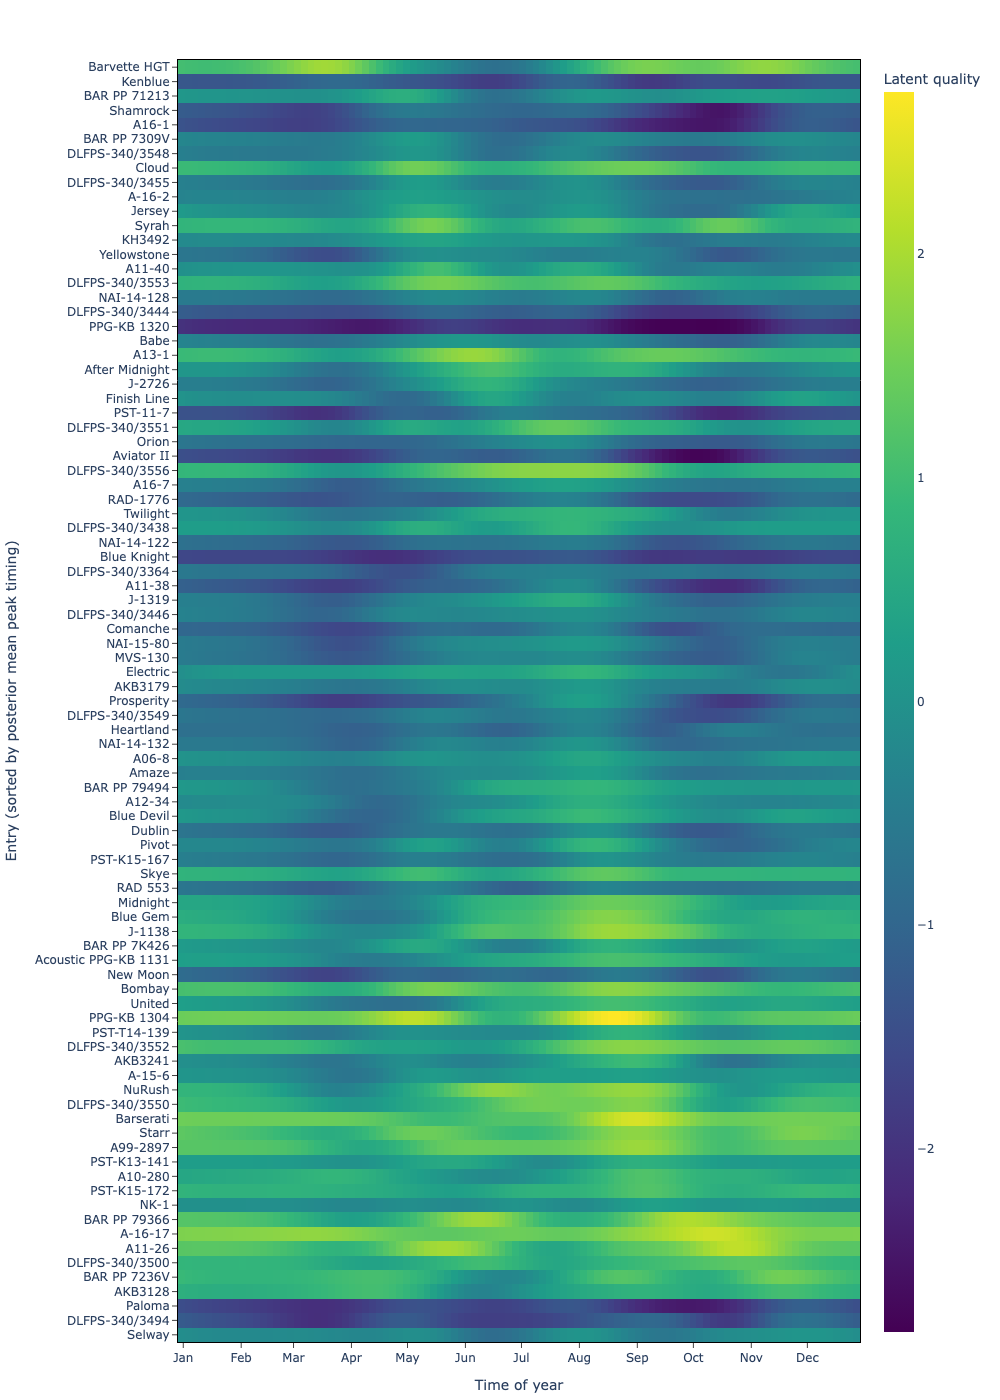

PosixPath('../reports/manuscript2/figure4c_all_entry_seasonality_heatmap.png')

In [16]:
fig = go.Figure(
    data=go.Heatmap(
        z=curve_matrix,
        colorscale='Viridis',
        colorbar=dict(title='Latent quality')
    )
)

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=month_positions,
        ticktext=month_labels,
        title='Time of year'
    ),
    yaxis=dict(
        title='Entry (sorted by posterior mean peak timing)',
        tickmode='array',
        tickvals=np.arange(len(ordered_entry_names)),
        ticktext=ordered_entry_names,
        autorange='reversed'
    ),
    margin=dict(l=10, r=10, b=10, t=60)

)

pio.kaleido.scope.default_width = 1000
pio.kaleido.scope.default_height = 1400
fig.show(renderer='png')
fig.write_image(appendix_fig_path)

appendix_fig_path

## Category Characteristic Curves

In [17]:
def plot_rater_characteristic_curve(
        betas,
        min_theta=-6,
        max_theta=6,
        resolution=500,
        colors=px.colors.diverging.BrBG,
        dimensions=None,
    ) -> go.Figure:
        """
        Plot the characteristic curves for raters based on the fitted Stan model.

        Args:
            rater_id (int, optional): The rater ID to plot. If None, all raters
                will be plotted. Defaults to None.
            dimensions (tuple, optional): Dimensions of the plot as (width, height).

        Returns:
            A Plotly figure object containing the plotted characteristic curves.
        """
        betas_with_bounds = np.concatenate(([min_theta], betas, [max_theta]))
        x = np.linspace(min_theta, max_theta, int((max_theta - min_theta) * resolution))
        num_categories = len(betas) + 1
        fig = go.Figure()
        fig.update_layout(
            xaxis_title='Turf Quality on Latent Scale',
            yaxis_title='Probability',
            legend=dict(x=1.02, y=1),
        )
        for i in range(num_categories):
            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=[rutils.rsm_probability(i, theta, betas) for theta in x],
                    line=dict(width=2, color=colors[i]),
                    name=str(i + 1),
                )
            )
            fig.add_shape(
                type='rect',
                x0=betas_with_bounds[i],
                x1=betas_with_bounds[i + 1],
                y0=1.02,
                y1=1.1,
                fillcolor=colors[i],
            )
            if i != num_categories - 1:
                fig.add_shape(
                    type='line',
                    x0=betas[i],
                    x1=betas[i],
                    y0=0,
                    y1=1,
                    line=dict(color=colors[i], dash='dot'),
                )
        if dimensions:
            fig.update_layout(width=dimensions[0], height=dimensions[1])
        return fig

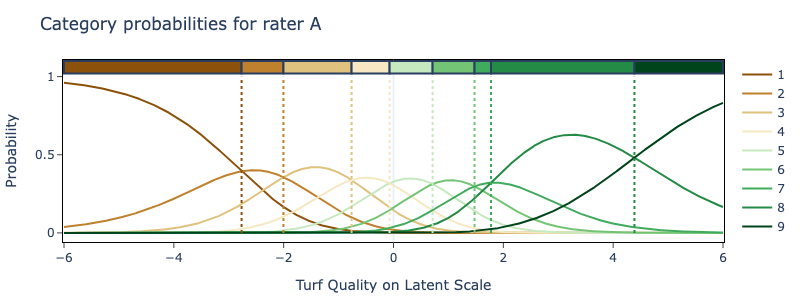

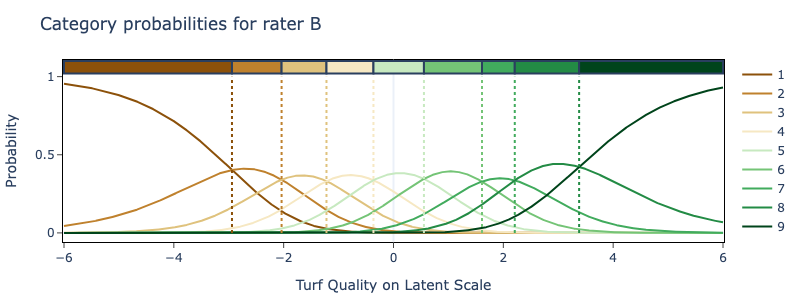

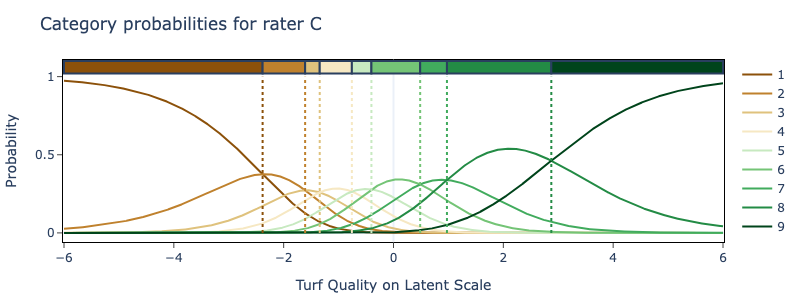

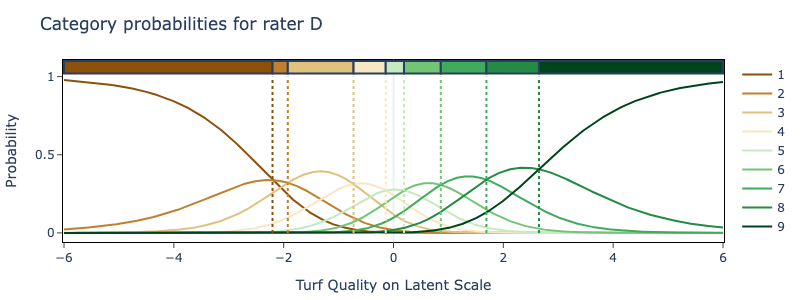

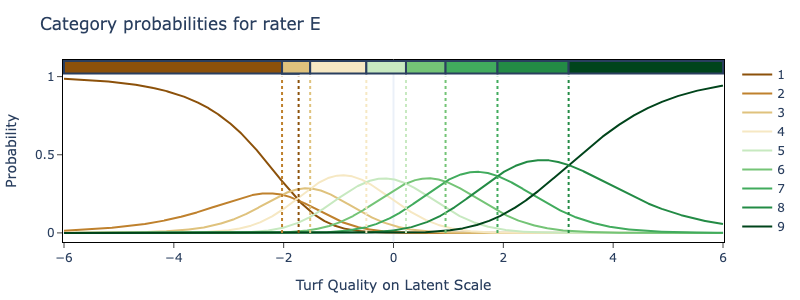

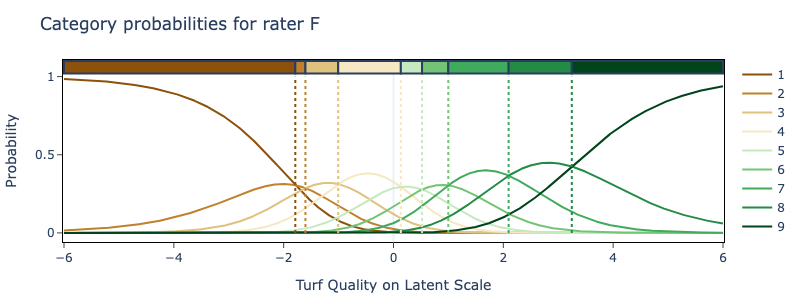

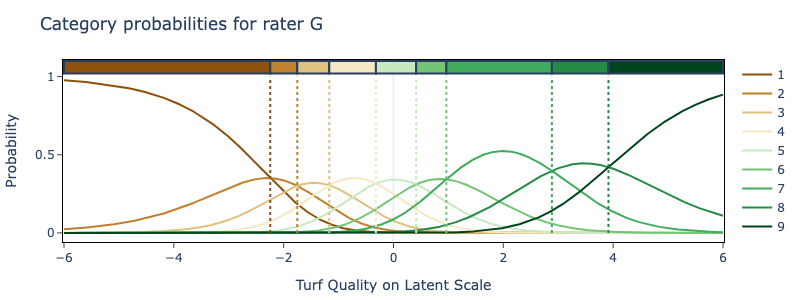

In [18]:
rater_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
for i in range(len(rater_list)):
    # make a figure
    fig = plot_rater_characteristic_curve(fit.tau_rater.mean(axis=0)[i,:], colors=NTEP_COLOR_SCALE_list)
    fig.update_layout(
        title=f'Category probabilities for rater {rater_list[i]}',
        margin=dict(l=10, r=10, b=10, t=60)
    )
    # adjust figure size here for static renderer for plotly
    pio.kaleido.scope.default_width = 800
    pio.kaleido.scope.default_height = 300
    fig.show(renderer='png') # change to renderer="iframe" for interactive plot
    #fig.write_image(f'figures/fig_cat_prob_{rater_list[i]}.png')

## Most probable rating outcomes

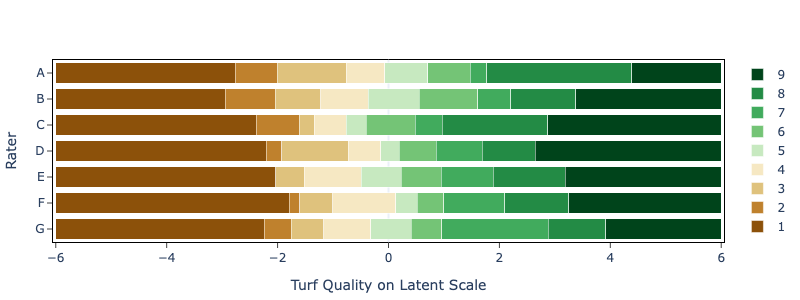

In [19]:
rater_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
thresholds = [fit.tau_rater.mean(axis=0)[i,:] for i in range(7)]
x_start, x_end = -6, 6

# make a figure
fig = go.Figure()

for i, (rater, rater_thresholds) in enumerate(zip(rater_list, thresholds)):
    # Add the start and end points for categories
    rater_thresholds = [x_start] + list(rater_thresholds) + [x_end]
    
    for j in range(len(rater_thresholds) - 1):
        # Add a rectangle for each category
        fig.add_trace(go.Bar(
            x=[rater_thresholds[j + 1] - rater_thresholds[j]],  # Width of the bar
            y=[rater],
            orientation='h',
            marker=dict(color=NTEP_COLOR_SCALE_list[j % len(NTEP_COLOR_SCALE_list)]),
            name=f"{j + 1}" if i == 0 else None,  # Show legend only for the first rater
            showlegend=(i == 0),  # Show legend only once
            base=rater_thresholds[j]
        ))

fig.update_yaxes(autorange='reversed')
fig.update_layout(
    barmode='stack',
    xaxis=dict(title='Turf Quality on Latent Scale', range=[x_start-0.05, x_end+0.05]),
    yaxis=dict(title='Rater', categoryorder='category ascending'),
    showlegend=True,
    margin=dict(l=10, r=10, b=10, t=60),
)

# adjust figure size here for static renderer for plotly
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 300
fig.show(renderer='png') # change to renderer="iframe" for interactive plot
#fig.write_image(f'figures/fig_probable_outcome.png')

In [20]:
[fit.tau_rater.mean(axis=0)[i,:] for i in range(7)]

[array([-2.7663388 , -2.00397591, -0.7630843 , -0.07129218,  0.71183392,
         1.47550488,  1.77543123,  4.38714699]),
 array([-2.94109981, -2.03786149, -1.22041913, -0.36493901,  0.55430947,
         1.61149822,  2.2082633 ,  3.38017377]),
 array([-2.38335855, -1.6092042 , -1.34333873, -0.75800833, -0.40209475,
         0.48568605,  0.97325197,  2.87386437]),
 array([-2.20279926, -1.92434534, -0.72743816, -0.14161175,  0.19102729,
         0.86135991,  1.69190426,  2.64878839]),
 array([-1.72779257, -2.02961458, -1.517441  , -0.49448922,  0.22733037,
         0.94794332,  1.89314144,  3.18928628]),
 array([-1.78790668, -1.6037737 , -1.0070698 ,  0.13362422,  0.52012379,
         0.99767877,  2.09663142,  3.24678299]),
 array([-2.24421134, -1.75171442, -1.16952406, -0.32039881,  0.41279631,
         0.9628251 ,  2.88415957,  3.91426093])]

## ELPD comparison

### Summary of the model comparison

The Seasonality Model is the top-ranked model under PSIS-LOO.

- Predictive fit is better: `elpd_loo = -15097.12` for the Seasonality Model versus `-15663.00` for the Spatial Model.
- The difference is large relative to its uncertainty: `elpd_diff = 565.88` with `diff SE = 48.14`.
- Effective complexity is also much higher in the Seasonality Model: `p_loo = 768.02` versus `254.04`.
- In the current implementation, the Seasonality Model is also faster to fit, with average sampling time about `79.96 ± 18.10` minutes versus `139.35 ± 15.90` minutes for the Spatial Model.
- All Pareto-`k` diagnostics were acceptable, so the PSIS-LOO comparison is stable rather than being driven by problematic observations.

Interpretation: the Seasonality Model is not simpler, but it delivers materially better out-of-sample predictive performance while preserving broadly similar spatial patterns and reducing runtime in this implementation.

In [21]:
azdata = az.from_cmdstanpy(fit)
azdata_old = az.from_cmdstanpy(fit_old_model)

In [22]:
%%time
az.loo(azdata)

CPU times: user 9.9 s, sys: 785 ms, total: 10.7 s
Wall time: 11.2 s


Computed from 6000 posterior samples and 9603 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -15097.12    72.22
p_loo      768.02        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     9603  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [23]:
%%time
az.loo(azdata_old)

CPU times: user 6.79 s, sys: 422 ms, total: 7.21 s
Wall time: 7.47 s


Computed from 6000 posterior samples and 9603 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -15663.00    68.80
p_loo      254.04        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     9603  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [24]:
# Make the comparison cell self-contained so it can be rerun without executing every prior ELPD cell.
if 'azdata' not in globals():
    azdata = az.from_cmdstanpy(fit)
if 'azdata_old' not in globals():
    azdata_old = az.from_cmdstanpy(fit_old_model)

# `az.compare` reports `elpd_diff` as the loss relative to the top-ranked model.
loo_new = az.loo(azdata)
loo_old = az.loo(azdata_old)
comparison_df = az.compare(
    {'Seasonality Model': azdata, 'Spatial Model': azdata_old},
    ic='loo'
 )

comparison_df[['rank', 'elpd_loo', 'p_loo', 'elpd_diff', 'weight', 'se', 'dse', 'warning']]

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning
Seasonality Model,0,-15097.117913,768.021717,0.000000,0.786349,72.22154,0.000000,False
Spatial Model,1,-15662.996942,254.040420,565.879029,0.213651,68.80381,48.135891,False


## Ablation ladder: deconfounding the temporal component from the rating-model parameterization

The headline model comparison above bundles two changes together: (i) replacing
the Cholesky spatial Gaussian process with a Hilbert-space + Fourier seasonality
component, and (ii) changing the rating model from the original
shared-threshold plus rating-event-adjustment specification to a
rater-specific-threshold specification without rating-event adjustments.
Because both changes are applied simultaneously, the overall `elpd_diff`
between the headline models cannot be attributed to either change on its own.

To deconfound those changes, we fit two additional ablation models and compare
all four on PSIS-LOO:

|                                 | Shared thresholds + event adjustment | Rater-specific thresholds |
|---------------------------------|--------------------------------------|---------------------------|
| **Spatial GP**                  | Spatial + original rating model *(baseline)* | Spatial + rater thresholds |
| **Seasonality + Fourier / Hilbert** | Seasonality + original rating model | Seasonality + rater thresholds *(full model)* |

This design identifies whether predictive improvements come primarily from the
temporal component, from the rating-model parameterization, or from their
combination. The off-diagonal comparisons should therefore be interpreted as
changes in the **rating model specification**, not as a pure threshold-only
contrast.


In [38]:
# Load the two ablation fits produced by:
#   nteprsm/model.py config/ablation_spatial_rater_thresholds_nj2.yml
#   nteprsm/model.py config/ablation_annual_old_thresholds_nj2.yml
fit_spatial_rater_path = DATA_DIR/'model_output/kb2017/fit_spatial_rater_thresholds_nj2_quality.pkl'
fit_annual_oldthr_path = DATA_DIR/'model_output/kb2017/fit_annual_old_thresholds_nj2_quality.pkl'

with open(fit_spatial_rater_path, 'rb') as f:
    fit_spatial_rater = pickle.load(f)
with open(fit_annual_oldthr_path, 'rb') as f:
    fit_annual_oldthr = pickle.load(f)

# Convert all four fits to ArviZ InferenceData for LOO.
# `fit` and `fit_old_model` are already loaded earlier in the notebook.
if 'azdata' not in globals():
    azdata = az.from_cmdstanpy(fit)
if 'azdata_old' not in globals():
    azdata_old = az.from_cmdstanpy(fit_old_model)
azdata_spatial_rater = az.from_cmdstanpy(fit_spatial_rater)
azdata_annual_oldthr = az.from_cmdstanpy(fit_annual_oldthr)


In [39]:
# Full ablation comparison: az.compare ranks all four models on PSIS-LOO and
# reports elpd_diff relative to the top-ranked model with its standard error.
ablation_models = {
    'Spatial + original rating model (baseline)':  azdata_old,
    'Spatial + rater thresholds':                  azdata_spatial_rater,
    'Seasonality + original rating model':        azdata_annual_oldthr,
    'Seasonality + rater thresholds (full)':      azdata,
}

ablation_compare = az.compare(ablation_models, ic='loo')
ablation_compare


/Users/henryqu/Library/Caches/pypoetry/virtualenvs/nteprsm-kiQW9mOZ-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Seasonality + original rating model,0,-14961.720250,665.607171,0.000000,0.656287,72.695427,0.000000,False,log
Seasonality + rater thresholds (full),1,-15097.117913,768.021717,135.397663,0.315411,72.221540,28.625152,False,log
Spatial + original rating model (baseline),2,-15662.996942,254.040420,701.276692,0.028303,68.803810,37.767127,False,log
Spatial + rater thresholds,3,-16069.232502,262.860649,1107.512253,0.000000,68.076988,50.592374,True,log


In [ ]:
from pathlib import Path
import pandas as pd
pred_draws = fit.pred_time_effect
pred_mean = pred_draws.mean(axis=0)
num_draws, num_entries, pred_n = pred_draws.shape
days = (np.arange(1, pred_n + 1) / pred_n) * 365.0
peak_idx = pred_draws.argmax(axis=2)
trough_idx = pred_draws.argmin(axis=2)
peak_day = days[peak_idx]
trough_day = days[trough_idx]
peak_value = pred_draws.max(axis=2)
trough_value = pred_draws.min(axis=2)
amplitude = peak_value - trough_value
annual_mean = pred_draws.mean(axis=2)
entry_lookup = (
    datahandler.model_data[['entry_code', 'entry_name']]
    .drop_duplicates()
    .sort_values('entry_code')
)
entry_names = entry_lookup['entry_name'].tolist()
peak_idx_mean = pred_mean.argmax(axis=1)
peak_day_mean_curve = days[peak_idx_mean]
sort_order = np.argsort(peak_day_mean_curve)
curve_matrix = pred_mean[sort_order, :]
ordered_entry_names = [entry_names[idx] for idx in sort_order]
ordered_peak_day_mean = peak_day_mean_curve[sort_order]
days_in_month = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
cumulative_days = np.cumsum(days_in_month)
month_positions = (cumulative_days[:-1] + 1) / 365.0 * pred_n
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_bins = np.array([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 366])

def day_to_month(day):
    month_idx = np.clip(np.digitize([day], month_bins, right=False)[0] - 1, 0, 11)
    return month_labels[month_idx]

# Cool-season turfgrasses typically peak before summer heat, slump during summer,
# and may rebound in the fall. Use biologically framed peak-group labels.
def peak_season_group(day):
    if day < 151:
        return 'Spring peak'
    if day < 243:
        return 'Summer peak'
    return 'Fall rebound'

def latex_escape(text):
    return (
        str(text)
        .replace('\\', r'\textbackslash{}')
        .replace('&', r'\&')
        .replace('%', r'\%')
        .replace('#', r'\#')
        .replace('_', r'\_')
    )

appendix_fig_path = Path('../reports/manuscript2/supplemental_figure_s1_all_entry_seasonality_heatmap.png')
appendix_curve_csv = Path('../data/processed/nj2_seasonality_curves_mean_matrix.csv')
appendix_summary_csv = Path('../data/processed/nj2_seasonality_summary_all_entries_full.csv')
appendix_review_table_csv = Path('../data/processed/nj2_seasonality_summary_review_table.csv')
supplemental_table_tex = Path('../reports/manuscript2/supplemental_table_s1.tex')
curve_export = (
    pd.DataFrame(curve_matrix, index=ordered_entry_names)
    .rename_axis('entry_name')
    .reset_index()
    .assign(peak_day_mean=ordered_peak_day_mean)
)
curve_export.to_csv(appendix_curve_csv, index=False)
summary_table = pd.DataFrame({
    'entry_code': entry_lookup['entry_code'].to_numpy(),
    'entry_name': entry_names,
    'annual_mean': annual_mean.mean(axis=0),
    'annual_mean_lb': np.quantile(annual_mean, 0.025, axis=0),
    'annual_mean_ub': np.quantile(annual_mean, 0.975, axis=0),
    'amplitude_mean': amplitude.mean(axis=0),
    'amplitude_lb': np.quantile(amplitude, 0.025, axis=0),
    'amplitude_ub': np.quantile(amplitude, 0.975, axis=0),
    'peak_day_mean': peak_day.mean(axis=0),
    'peak_day_lb': np.quantile(peak_day, 0.025, axis=0),
    'peak_day_ub': np.quantile(peak_day, 0.975, axis=0),
    'trough_day_mean': trough_day.mean(axis=0),
    'trough_day_lb': np.quantile(trough_day, 0.025, axis=0),
    'trough_day_ub': np.quantile(trough_day, 0.975, axis=0),
    'peak_day_mean_curve': peak_day_mean_curve,
})
summary_table['peak_month'] = summary_table['peak_day_mean'].apply(day_to_month)
summary_table['trough_month'] = summary_table['trough_day_mean'].apply(day_to_month)
summary_table['peak_season_group'] = summary_table['peak_day_mean'].apply(peak_season_group)
summary_table = summary_table.iloc[sort_order].reset_index(drop=True)
summary_table['peak_rank'] = np.arange(1, len(summary_table) + 1)
summary_table.to_csv(appendix_summary_csv, index=False)
review_table = summary_table[[
    'peak_rank',
    'entry_name',
    'peak_season_group',
    'peak_month',
    'trough_month',
    'amplitude_mean',
    'amplitude_lb',
    'amplitude_ub',
    'peak_day_mean',
    'peak_day_lb',
    'peak_day_ub',
    'trough_day_mean',
    'trough_day_lb',
    'trough_day_ub',
    'annual_mean',
]].copy()
review_table['amplitude_mean_95ci'] = review_table.apply(
    lambda row: f"{row['amplitude_mean']:.2f} [{row['amplitude_lb']:.2f}, {row['amplitude_ub']:.2f}]",
    axis=1,
)
review_table['peak_day_mean_fmt'] = review_table['peak_day_mean'].map(lambda value: f"{value:.1f}")
review_table['trough_day_mean_fmt'] = review_table['trough_day_mean'].map(lambda value: f"{value:.1f}")
review_table.to_csv(appendix_review_table_csv, index=False)
latex_lines = [
    r'\begingroup',
    r'\footnotesize',
    r'\setlength{\LTpre}{0pt}',
    r'\setlength{\LTpost}{0pt}',
    r'\setlength{\tabcolsep}{0.8pt}',
    r'\begin{longtable}{@{}c>{\centering\arraybackslash}p{1.50in}>{\centering\arraybackslash}p{0.92in}>{\centering\arraybackslash}p{0.34in}>{\centering\arraybackslash}p{0.40in}>{\centering\arraybackslash}p{0.90in}>{\centering\arraybackslash}p{0.58in}>{\centering\arraybackslash}p{0.60in}c@{}}',
    r'\hline',
    r'Rank & Entry & Group & Peak & Trough & Amplitude & Peak day & Trough day & Mean \\',
    r'\hline',
    r'\endfirsthead',
    r'\hline',
    r'Rank & Entry & Group & Peak & Trough & Amplitude & Peak day & Trough day & Mean \\',
    r'\hline',
    r'\endhead',
    r'\hline',
    r'\endfoot',
    r'\hline',
    r'\endlastfoot',
]
for row in review_table.itertuples(index=False):
    latex_lines.append(
        f"{row.peak_rank} & {latex_escape(row.entry_name)} & {row.peak_season_group} & "
        f"{row.peak_month} & {row.trough_month} & {row.amplitude_mean_95ci} & "
        f"{row.peak_day_mean_fmt} & {row.trough_day_mean_fmt} & {row.annual_mean:.2f} \\\\"
    )
latex_lines.extend([
    r'\end{longtable}',
    r'\endgroup',
])
supplemental_table_tex.write_text('\n'.join(latex_lines) + '\n')
review_preview = pd.concat([
    review_table.head(5),
    review_table.tail(5),
]).reset_index(drop=True)
review_preview[[
    'peak_rank',
    'entry_name',
    'peak_season_group',
    'peak_month',
    'trough_month',
    'amplitude_mean_95ci',
    'peak_day_mean_fmt',
    'trough_day_mean_fmt',
    'annual_mean',
]]

/Users/henryqu/Library/Caches/pypoetry/virtualenvs/nteprsm-kiQW9mOZ-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.

/Users/henryqu/Library/Caches/pypoetry/virtualenvs/nteprsm-kiQW9mOZ-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential obs

,from (A),to (B),elpd_A,elpd_B,elpd_diff (B - A),elpd_diff_SE,z = diff / SE
0,Spatial + original rating model,Spatial + rater thresholds,-15663.00,-16069.23,-406.24,36.51,-11.13
1,Seasonality + original rating model,Seasonality + rater thresholds,-14961.72,-15097.12,-135.40,28.63,-4.73
2,Spatial + original rating model,Seasonality + original rating model,-15663.00,-14961.72,701.28,37.77,18.57
3,Spatial + rater thresholds,Seasonality + rater thresholds,-16069.23,-15097.12,972.11,42.38,22.94
4,Spatial + original rating model,Seasonality + rater thresholds (full),-15663.00,-15097.12,565.88,48.14,11.76


### Summary of the ablation comparison

The four models rank on PSIS-LOO (best to worst) as:

| Rank | Model | `elpd_loo` | `p_loo` | `elpd_diff` vs top | `dse` | warning |
|------|-------|------------|---------|---------------------|-------|---------|
| 0 | Seasonality + original rating model | -14961.72 | 665.6 | 0.00 | 0.0 | False |
| 1 | Seasonality + rater thresholds (full) | -15097.12 | 768.0 | 135.40 | 28.6 | False |
| 2 | Spatial + original rating model (baseline) | -15663.00 | 254.0 | 701.28 | 37.8 | False |
| 3 | Spatial + rater thresholds | -16069.23 | 262.9 | 1107.51 | 50.6 | True |

Paired contrasts, with SE computed from paired pointwise `elpd` differences:

| Held fixed | Change (A → B) | `elpd_diff = elpd(B) - elpd(A)` | SE | z |
|------------|----------------|----------------------------------|----|---|
| Spatial structure | original rating model → rater thresholds | -406.24 | 36.5 | -11.1 |
| Seasonality structure | original rating model → rater thresholds | -135.40 | 28.6 | -4.7 |
| Original rating model | spatial → seasonality | +701.28 | 37.8 | +18.6 |
| Rater-threshold rating model | spatial → seasonality | +972.11 | 42.4 | +22.9 |
| Bundled comparison | spatial + original rating model → seasonality + rater thresholds | +565.88 | 48.1 | +11.8 |

**Rigorous interpretation:**

1. **The temporal component is the dominant source of predictive improvement.**
   Replacing the spatial-only structure with the seasonality component improves
   `elpd` substantially under either rating-model parameterization (+701 and
   +972, respectively).

2. **Within this 2x2 design, the original rating-model parameterization
   outperforms the rater-threshold parameterization for NJ2.** Both seasonality
   and spatial variants lose predictive fit when moving away from the original
   shared-threshold plus rating-event-adjustment formulation. That should be
   described as a rating-model-specification result, not as a pure
   threshold-only result.

3. **The bundled headline gain of +565.88 is real, but it is not attributable
   to both changes in the same direction.** The gain reflects a large positive
   contribution from the seasonality component, partly offset by a negative
   contribution from switching the rating-model specification.

4. **The ranking is directionally informative, but the evidence is not as clean
   as a fully converged comparison would be.** The PSIS-LOO table flags the
   Spatial + rater-thresholds model with `warning = True` and one Pareto-`k`
   value above 0.7. In addition, the sampler diagnostics show nonzero
   divergences in all four fitted models (38, 28, 37, and 30, respectively).
   These issues do not erase the large `elpd` gaps, but they mean the A3
   response should be framed as **strong but still somewhat diagnostics-limited
   evidence**, not as a completely settled decomposition.

A defensible response to the reviewer is therefore: the predictive advantage of
the headline model comparison is driven primarily by the seasonality component,
while the alternate rating-model parameterization does not explain the gain and,
in this dataset, slightly reduces predictive performance relative to the
original rating model.
